# 2026_07_31_Lisa — pooled MB / ALL intensity analysis

For every scene that has both registered masks (`msk_MB_registered_s<s>.tif` and
`..._s<s>_ALL.tif`, produced by `26_07_31_Lisa_MB_registration_condensed.ipynb`):
apply each mask to the BRP channel (ch0, nc82/Alexa488) and the 5HT channel (ch1, Alexa647)
and take the **mean intensity over all mask voxels**.

Groups by scene index: **Control** 0–5, **Alpha** 6–11, **Psi** 12–17.

Per (channel, mask) one bar plot (Control / Alpha / Psi, mean ± SEM + points), plus the
5HT-normalised-to-BRP ratio per mask. Plotting + stats via `fast_plotter` (unpaired: the three
groups are different animals → Kruskal-Wallis / one-way ANOVA chosen by normality, with
post-hoc), same as `pooled_results.ipynb`.

Data structure: one **pandas DataFrame** row per scene (saved to
`pooled_intensity_results.csv`) — the project's plot/stat helpers consume DataFrames, it groups
trivially, and it round-trips to CSV for reuse.

In [9]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, platform
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

system = platform.system()
home = {'Linux': '/home/gerard/', 'Darwin': '/Users/gerard/', 'Windows': 'C:/Users/cviko/'}[system]
try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import describe_acquisition
    from plotter import fast_plotter
except ImportError:
    sys.path.append(home + 'analysis/confocal/src')
    from data_processing import describe_acquisition
    from plotter import fast_plotter

date, user = '2026_07_31', 'Lisa'
base = home + f'data/confocal/{date}_{user}/'
lif_path = base + 'Project.lif'

GROUP_ORDER  = ['Control', 'Alpha', 'Psi']
GROUP_COLORS = ['#b0b0b0', '#4C72B0', '#C44E52']   # Control grey, Alpha blue, Psi red

def group_of(scene):
    return 'Control' if scene <= 5 else 'Alpha' if scene <= 11 else 'Psi'

try:
    scene_names = list(describe_acquisition(lif_path, do_print=False).keys())
except Exception as e:
    print('describe_acquisition failed, using generic names:', e)
    scene_names = [f'scene_{s}' for s in range(18)]
print({s: (scene_names[s], group_of(s)) for s in range(18)})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{0: ('control_brain_1', 'Control'), 1: ('control_brain_2', 'Control'), 2: ('control_brain_3', 'Control'), 3: ('control_brain_4', 'Control'), 4: ('control_brain_5', 'Control'), 5: ('control_brain_6', 'Control'), 6: ('alphaTry_brain_1', 'Alpha'), 7: ('alphaTry_brain_2', 'Alpha'), 8: ('alphaTry_brain_3', 'Alpha'), 9: ('alphaTry_brain_4', 'Alpha'), 10: ('alphaTry_brain_5', 'Alpha'), 11: ('alphaTry_brain_6', 'Alpha'), 12: ('Psi_brain_1', 'Psi'), 13: ('Psi_brain_2', 'Psi'), 14: ('Psi_brain_3', 'Psi'), 15: ('Psi_brain_4', 'Psi'), 16: ('Psi_brain_5', 'Psi'), 17: ('Psi_brain_6', 'Psi')}


In [10]:
# ─── collect: for every scene with BOTH masks, mean channel intensity inside MB and ALL ───
CH = {'BRP': 'channel_0', '5HT': 'channel_1'}   # ch0 = nc82/BRP, ch1 = 5HT

rows = []
for s in range(18):
    d = base + f'series_{s}/'
    mp = {'MB': d + f'masks/msk_MB_registered_s{s}.tif',
          'ALL': d + f'masks/msk_MB_registered_s{s}_ALL.tif'}
    if not all(os.path.exists(p) for p in mp.values()):
        print(f's{s:2d} {group_of(s):7s} — no masks, skip'); continue
    chp = {c: glob.glob(d + f'{sub}/*.tif') for c, sub in CH.items()}
    if not all(chp.values()):
        print(f's{s:2d} {group_of(s):7s} — masks present but a channel .tif is missing, skip'); continue

    masks = {k: tifffile.imread(p).astype(bool) for k, p in mp.items()}
    imgs  = {c: tifffile.imread(sorted(v)[0]) for c, v in chp.items()}
    shp = next(iter(masks.values())).shape
    assert all(a.shape == shp for a in list(masks.values()) + list(imgs.values())), \
        f's{s}: shape mismatch {[a.shape for a in list(masks.values()) + list(imgs.values())]}'

    rec = {'scene': s, 'name': scene_names[s], 'group': group_of(s),
           'MB_voxels': int(masks['MB'].sum()), 'ALL_voxels': int(masks['ALL'].sum())}
    for c in CH:
        for m in ('MB', 'ALL'):
            rec[f'{c}_{m}'] = float(imgs[c][masks[m]].mean())   # mean over ALL mask voxels
    for m in ('MB', 'ALL'):
        rec[f'5HT_over_BRP_{m}'] = rec[f'5HT_{m}'] / rec[f'BRP_{m}']
    rows.append(rec)
    print(f's{s:2d} {group_of(s):7s} {scene_names[s]:16s} | '
          f'BRP MB/ALL {rec["BRP_MB"]:6.1f}/{rec["BRP_ALL"]:6.1f}  '
          f'5HT MB/ALL {rec["5HT_MB"]:6.1f}/{rec["5HT_ALL"]:6.1f}  '
          f'5HT/BRP MB {rec["5HT_over_BRP_MB"]:.2f}')

results = pd.DataFrame(rows)
csv_path = base + 'pooled_intensity_results.csv'
results.to_csv(csv_path, index=False)
print(f'\n{len(results)} scenes -> {csv_path}')
print(results.groupby('group').size().reindex(GROUP_ORDER).to_string())
results

s 0 Control control_brain_1  | BRP MB/ALL   71.3/  38.1  5HT MB/ALL   30.9/  19.1  5HT/BRP MB 0.43
s 1 Control control_brain_2  | BRP MB/ALL   87.9/  36.6  5HT MB/ALL   54.4/  22.8  5HT/BRP MB 0.62
s 2 Control control_brain_3  | BRP MB/ALL   52.3/  32.7  5HT MB/ALL   53.3/  23.7  5HT/BRP MB 1.02
s 3 Control control_brain_4  | BRP MB/ALL   75.0/  33.9  5HT MB/ALL   47.3/  21.3  5HT/BRP MB 0.63
s 4 Control control_brain_5  | BRP MB/ALL   73.2/  32.2  5HT MB/ALL   78.6/  27.2  5HT/BRP MB 1.07
s 5 Control control_brain_6  | BRP MB/ALL  116.9/  38.7  5HT MB/ALL   62.2/  22.1  5HT/BRP MB 0.53
s 6 Alpha   alphaTry_brain_1 | BRP MB/ALL   52.2/  25.4  5HT MB/ALL   34.6/  14.8  5HT/BRP MB 0.66
s 7 Alpha   alphaTry_brain_2 | BRP MB/ALL   78.7/  31.3  5HT MB/ALL   34.2/  15.2  5HT/BRP MB 0.43
s 8 Alpha   alphaTry_brain_3 | BRP MB/ALL   62.9/  38.2  5HT MB/ALL   65.8/  23.1  5HT/BRP MB 1.05
s 9 Alpha   alphaTry_brain_4 | BRP MB/ALL   54.1/  28.5  5HT MB/ALL   42.6/  18.3  5HT/BRP MB 0.79
s10 Alpha 

,scene,name,group,MB_voxels,ALL_voxels,BRP_MB,BRP_ALL,5HT_MB,5HT_ALL,5HT_over_BRP_MB,5HT_over_BRP_ALL
0,0,control_brain_1,Control,1640337,44622406,71.284236,38.126475,30.854941,19.104380,0.432844,0.501079
1,1,control_brain_2,Control,1528129,44220490,87.896358,36.572661,54.447477,22.793770,0.619451,0.623246
2,2,control_brain_3,Control,1492231,43147448,52.263765,32.674204,53.322974,23.747994,1.020267,0.726812
3,3,control_brain_4,Control,1678270,53473580,75.032942,33.903579,47.328568,21.335571,0.630771,0.629301
4,4,control_brain_5,Control,1372751,50158553,73.227415,32.156736,78.573754,27.212004,1.073010,0.846230
5,5,control_brain_6,Control,1379384,58432902,116.873742,38.663042,62.180038,22.120939,0.532027,0.572147
6,6,alphaTry_brain_1,Alpha,1516743,63360275,52.173228,25.402028,34.582406,14.803427,0.662838,0.582766
7,7,alphaTry_brain_2,Alpha,1762911,61452273,78.733751,31.301664,34.224491,15.212693,0.434686,0.486003
8,8,alphaTry_brain_3,Alpha,1509897,59933203,62.923384,38.159716,65.805879,23.076071,1.045810,0.604723
9,9,alphaTry_brain_4,Alpha,1435446,45192945,54.127910,28.523118,42.604686,18.345224,0.787111,0.643170



=================  BRP mean intensity — MB mask  =================

---------- STATS ----------
Control
  W statistic = 0.9203
  p-value     = 0.5075
  → Data look approximately normal

Alpha
  W statistic = 0.9416
  p-value     = 0.6771
  → Data look approximately normal

Psi
  W statistic = 0.9068
  p-value     = 0.4154
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.3544
p-value   = 0.7077
→ Variances are not significantly different

One-way ANOVA
F statistic = 4.4007
p-value     = 0.0329
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.3860
Effect size interpretation: large
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
  Alpha Control  16.2572 0.3011 -11.2874 43.8017  False
  Alpha     Psi  31.2088  0.026   3.6642 58.7533   True
Control     Psi  14.9516 0.3251 -11.3111 41.2143  False
-----------------------

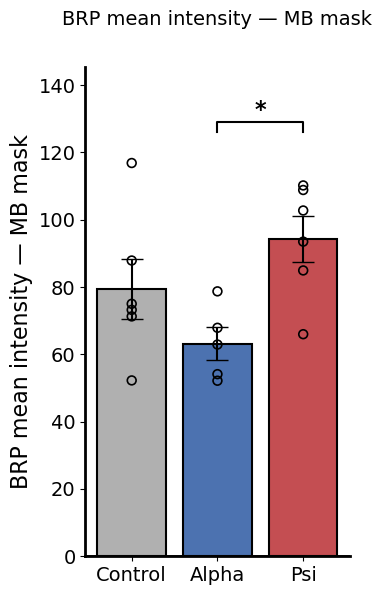


=================  BRP mean intensity — ALL mask  =================

---------- STATS ----------
Control
  W statistic = 0.8932
  p-value     = 0.3352
  → Data look approximately normal

Alpha
  W statistic = 0.9651
  p-value     = 0.8428
  → Data look approximately normal

Psi
  W statistic = 0.9290
  p-value     = 0.5722
  → Data look approximately normal

Brown-Forsythe test
Statistic = 4.3160
p-value   = 0.0347
→ Variances differ significantly

Kruskal-Wallis test
H statistic = 8.2222
p-value     = 0.0164
→ Significant differences exist between groups

Control vs Alpha: p_adj = 0.2468 ns
Control vs Psi: p_adj = 0.0519 ns
Alpha vs Psi: p_adj = 0.0519 ns
group: Control, mean: 35.34944930670618, sem: 1.1493318560225887
group: Alpha, mean: 31.851303147622353, sem: 2.333645014599225
group: Psi, mean: 45.36168422473636, sem: 3.1235706227088245


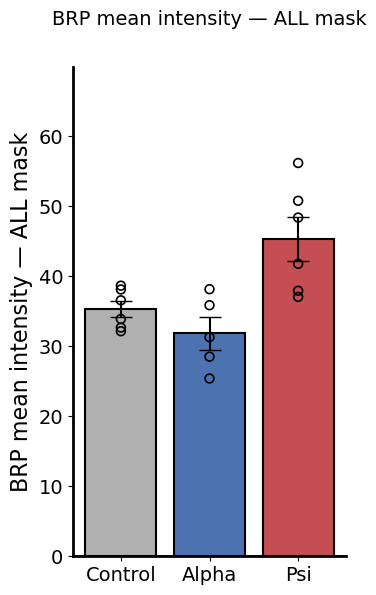


=================  5HT mean intensity — MB mask  =================

---------- STATS ----------
Control
  W statistic = 0.9769
  p-value     = 0.9350
  → Data look approximately normal

Alpha
  W statistic = 0.8157
  p-value     = 0.1082
  → Data look approximately normal

Psi
  W statistic = 0.9270
  p-value     = 0.5575
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.3050
p-value   = 0.7419
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.6933
p-value     = 0.2195
→ No significant differences detected


Effect size
Eta squared (η²) = 0.1948
Effect size interpretation: large
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
  Alpha Control  13.0886 0.2607  -7.7512 33.9284  False
  Alpha     Psi   1.6179 0.9775 -19.2218 22.4577  False
Control     Psi -11.4707 0.3158 -31.3406  8.3993  False
--------------------------------

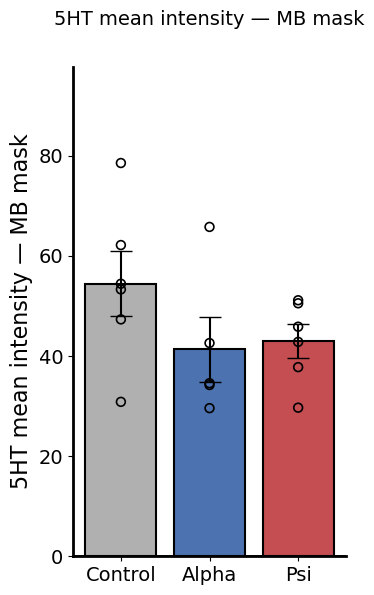


=================  5HT mean intensity — ALL mask  =================

---------- STATS ----------
Control
  W statistic = 0.9674
  p-value     = 0.8748
  → Data look approximately normal

Alpha
  W statistic = 0.8928
  p-value     = 0.3716
  → Data look approximately normal

Psi
  W statistic = 0.9630
  p-value     = 0.8422
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.0799
p-value   = 0.9237
→ Variances are not significantly different

One-way ANOVA
F statistic = 4.5475
p-value     = 0.0301
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.3938
Effect size interpretation: large
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
  Alpha Control   4.8296 0.0365  0.2912  9.368   True
  Alpha     Psi   0.9536 0.8482 -3.5848  5.492  False
Control     Psi   -3.876 0.0821 -8.2032 0.4511  False
----------------------------------

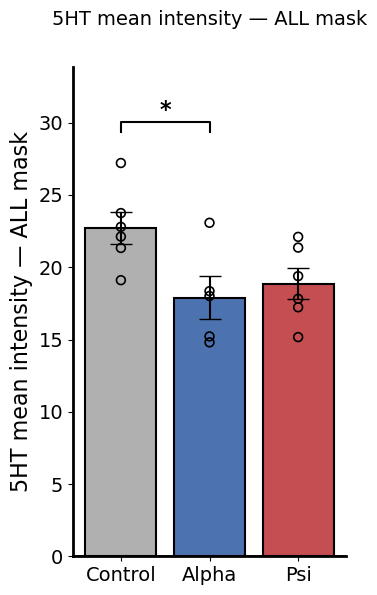


=================  5HT / BRP — MB mask  =================

---------- STATS ----------
Control
  W statistic = 0.8617
  p-value     = 0.1951
  → Data look approximately normal

Alpha
  W statistic = 0.9091
  p-value     = 0.4621
  → Data look approximately normal

Psi
  W statistic = 0.9440
  p-value     = 0.6914
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.1731
p-value   = 0.3380
→ Variances are not significantly different

One-way ANOVA
F statistic = 2.1947
p-value     = 0.1482
→ No significant differences detected


Effect size
Eta squared (η²) = 0.2387
Effect size interpretation: large
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
  Alpha Control   0.0448 0.9398 -0.3039 0.3935  False
  Alpha     Psi  -0.2065 0.2989 -0.5552 0.1422  False
Control     Psi  -0.2513 0.1543 -0.5837 0.0812  False
-----------------------------------------------------

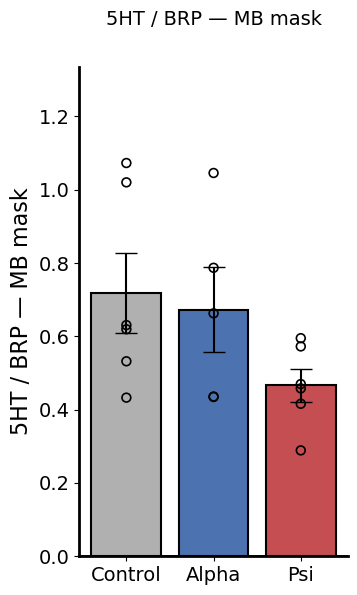


=================  5HT / BRP — ALL mask  =================

---------- STATS ----------
Control
  W statistic = 0.9580
  p-value     = 0.8041
  → Data look approximately normal

Alpha
  W statistic = 0.9179
  p-value     = 0.5165
  → Data look approximately normal

Psi
  W statistic = 0.8257
  p-value     = 0.0988
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.9891
p-value   = 0.3965
→ Variances are not significantly different

One-way ANOVA
F statistic = 10.4642
p-value     = 0.0017
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.5992
Effect size interpretation: large
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Alpha Control   0.0861 0.2697 -0.0529   0.225  False
  Alpha     Psi  -0.1434 0.0428 -0.2824 -0.0045   True
Control     Psi  -0.2295 0.0013 -0.3619  -0.097   True
------------------------------------

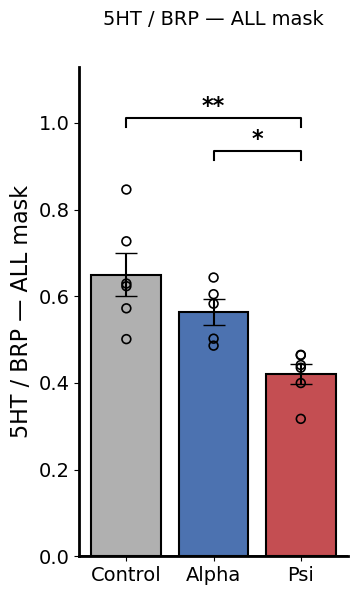

In [11]:
# ─── one bar plot per (channel, mask), plus the 5HT/BRP ratio per mask ───
def _wide(df, col):
    """Reshape to the wide frame fast_plotter expects: one column per group, rows = scenes."""
    return pd.DataFrame({g: pd.Series(df.loc[df.group == g, col].to_numpy(float))
                         for g in GROUP_ORDER})

PLOTS = [
    ('BRP_MB',           'BRP mean intensity — MB mask'),
    ('BRP_ALL',          'BRP mean intensity — ALL mask'),
    ('5HT_MB',           '5HT mean intensity — MB mask'),
    ('5HT_ALL',          '5HT mean intensity — ALL mask'),
    ('5HT_over_BRP_MB',  '5HT / BRP — MB mask'),
    ('5HT_over_BRP_ALL', '5HT / BRP — ALL mask'),
]

for col, title in PLOTS:
    print(f'\n=================  {title}  =================')
    fast_plotter(GROUP_ORDER, df=_wide(results, col),
                 ylabel=title, title=title, labels=GROUP_ORDER,
                 bar_color=GROUP_COLORS, figsize=(3.5, 6), quietStats=False)

In [12]:
# group sizes / means table (quick reference alongside the figures above)
summary = (results
           .groupby('group')[[c for c, _ in PLOTS]]
           .agg(['count', 'mean', 'sem'])
           .reindex(GROUP_ORDER))
summary

BRP_MB                      BRP_ALL                      5HT_MB  \
         count       mean       sem   count       mean       sem  count   
group                                                                     
Control      6  79.429743  8.823977       6  35.349449  1.149332      6   
Alpha        5  63.172579  4.834233       5  31.851303  2.333645      5   
Psi          6  94.381335  6.893567       6  45.361684  3.123571      6   

                             5HT_ALL                      5HT_over_BRP_MB  \
              mean       sem   count       mean       sem           count   
group                                                                       
Control  54.451292  6.456059       6  22.719110  1.104363               6   
Alpha    41.362682  6.459080       5  17.889501  1.480066               5   
Psi      42.980616  3.346099       6  18.843075  1.070889               6   

                            5HT_over_BRP_ALL                      
             mean       sem            count      mean       sem  
group                                                             
Control  0.718062  0.108108                6  0.649803  0.049595  
Alpha    0.673258  0.115141                5  0.563751  0.030161  
Psi      0.466789  0.045437                6  0.420344  0.022820